# CIFAR-10 Image Classification: ANN vs CNN Architectures



---
## 1. Environment Setup & Imports

We import everything up front so the notebook's dependencies are visible at a glance. We also fix random seeds for reproducibility -- this matters in an academic context because it lets the comparison between models be attributed to *architecture*, not to random initialization luck.


In [2]:
# =============================================================================
# SECTION 1: IMPORTS & REPRODUCIBILITY SETUP
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow version: 2.16.2
GPU available: True


---
## 2. Dataset Loading & Exploration

CIFAR-10 ships directly with Keras (`tf.keras.datasets.cifar10`), so no manual download is required. It contains:

- **50,000 training images** and **10,000 test images**
- Each image is **32x32 pixels, RGB (3 channels)**
- **10 mutually exclusive classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

We load the data, inspect shapes, and visualize a sample grid to confirm everything loaded correctly before building any models -- a sanity check every CV engineer should do before writing model code.


In [3]:
# =============================================================================
# SECTION 2: LOAD CIFAR-10 DATASET
# =============================================================================

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# y_train/y_test arrive as shape (N, 1); flatten to (N,) since
# SparseCategoricalCrossentropy expects 1-D integer labels.
y_train = y_train.flatten()
y_test = y_test.flatten()

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("x_train shape:", x_train.shape)   # (50000, 32, 32, 3)
print("y_train shape:", y_train.shape)   # (50000,)
print("x_test shape :", x_test.shape)    # (10000, 32, 32, 3)
print("y_test shape :", y_test.shape)    # (10000,)
print("Pixel value range (raw):", x_train.min(), "-", x_train.max())


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1386s 8us/step
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000,)
x_test shape : (10000, 32, 32, 3)
y_test shape : (10000,)
Pixel value range (raw): 0 - 255


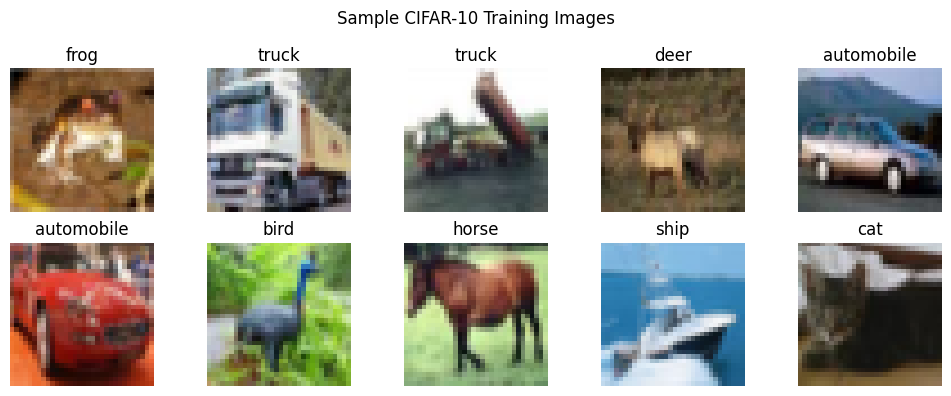

In [4]:
# ---- Visualize a sample grid of training images ---------------------------
# Confirms images and labels are correctly aligned before any modeling work.

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Training Images")
plt.tight_layout()
plt.show()


---
## 3. Preprocessing -- Normalization

Raw pixel values range from **0-255** (8-bit integers). Neural networks train far more reliably on **small, zero-centered-ish inputs**:

- Large raw inputs (up to 255) cause large initial activations and gradients, which can lead to unstable training and slower convergence.
- Dividing by 255.0 rescales every pixel into **[0, 1]**, which keeps activations and gradients in a numerically well-behaved range for Adam and BatchNorm to work effectively.

We deliberately do **not** one-hot encode the labels, because we are using `SparseCategoricalCrossentropy`, which consumes integer class labels (0-9) directly -- this is both simpler and slightly more memory-efficient than one-hot vectors for a 10-class problem.


In [5]:
# =============================================================================
# SECTION 3: PREPROCESSING -- NORMALIZE PIXEL VALUES TO [0, 1]
# =============================================================================

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("Normalized pixel range:", x_train_norm.min(), "-", x_train_norm.max())
print("Data type:", x_train_norm.dtype)

# Labels remain integers 0-9 (no one-hot encoding needed for
# SparseCategoricalCrossentropy).
print("Unique labels:", np.unique(y_train))


Normalized pixel range: 0.0 - 1.0
Data type: float32
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [6]:
# =============================================================================
# SECTION 4: BASELINE ANN MODEL
# =============================================================================

def build_baseline_ann():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),                       # unroll image into a vector
        layers.Dense(256, activation='relu'),   # hidden layer 1
        layers.Dropout(0.3),                    # regularization
        layers.Dense(128, activation='relu'),   # hidden layer 2
        layers.Dropout(0.3),                    # regularization
        layers.Dense(10, activation='softmax')  # output: 10 class probabilities
    ], name="Baseline_ANN")
    return model

ann_baseline = build_baseline_ann()

ann_baseline.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

ann_baseline.summary()


2026-06-21 12:47:49.301747: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-06-21 12:47:49.302700: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-21 12:47:49.304276: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-21 12:47:49.304348: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-21 12:47:49.305611: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ---- Train Baseline ANN for 10 epochs --------------------------------------
start = time.time()

history_ann = ann_baseline.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    verbose=1
)

print(f"Baseline ANN training time: {time.time() - start:.1f}s")


Epoch 1/10


2026-06-21 12:47:52.179058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.1229 - loss: 13.7497 - val_accuracy: 0.1743 - val_loss: 2.3655
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1468 - loss: 2.4934 - val_accuracy: 0.1555 - val_loss: 2.2523
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1689 - loss: 2.3106 - val_accuracy: 0.1805 - val_loss: 2.1960
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1932 - loss: 2.2648 - val_accuracy: 0.1851 - val_loss: 2.2008
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2133 - loss: 2.2296 - val_accuracy: 0.1966 - val_loss: 2.1426
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.2257 - loss: 2.2102 - val_accuracy: 0.1984 - val_loss: 2.2341
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.2310 - loss: 2.2398 - val_accuracy: 0.2274 - val_loss: 2.1167
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.2289 - loss: 2.2917 - val_accuracy:

---
## 5. Baseline Convolutional Neural Network (CNN)

**Architecture rationale:**

| Layer | Purpose |
|---|---|
| `Conv2D(32, 3x3, relu)` | Learns 32 low-level local feature detectors (edges, color gradients, simple textures). Convolution preserves spatial structure, unlike Flatten. |
| `BatchNormalization` | Normalizes activations within each mini-batch, stabilizing and accelerating training. |
| `MaxPooling2D(2x2)` | Downsamples spatial dimensions by half, reducing computation and providing a degree of translation invariance. |
| `Conv2D(64, 3x3, relu)` | Learns 64 higher-level features built from the first layer's outputs (e.g., shapes, simple parts). |
| `BatchNormalization` + `MaxPooling2D` | Same purposes as above, applied at the next scale. |
| `Flatten` | Converts the final feature maps into a 1-D vector for the classifier head. |
| `Dense(128, relu)` + `Dropout(0.3)` | Fully-connected classifier head with regularization. |
| `Dense(10, softmax)` | Final class probabilities. |

**Why CNNs are well-suited to images:** Convolution kernels are applied with **shared weights across all spatial locations**, which means a "vertical edge detector" learned in the top-left of the image is automatically reused everywhere else in the image. This gives CNNs translation invariance and dramatically fewer parameters than an equivalently-sized Dense network -- both of which directly combat overfitting on visual data.


In [8]:
# =============================================================================
# SECTION 5: BASELINE CNN MODEL
# =============================================================================

def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name="Baseline_CNN")
    return model

cnn_baseline = build_baseline_cnn()

cnn_baseline.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cnn_baseline.summary()


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

In [9]:
# ---- Train Baseline CNN for 10 epochs ---------------------------------------
start = time.time()

history_cnn = cnn_baseline.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    verbose=1
)

print(f"Baseline CNN training time: {time.time() - start:.1f}s")


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.3633 - loss: 5.5937 - val_accuracy: 0.5496 - val_loss: 1.6790
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5244 - loss: 1.7183 - val_accuracy: 0.6265 - val_loss: 1.0998
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5937 - loss: 1.2167 - val_accuracy: 0.6039 - val_loss: 1.1637
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.6129 - loss: 1.1829 - val_accuracy: 0.6073 - val_loss: 1.2516
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.6253 - loss: 1.2246 - val_accuracy: 0.5979 - val_loss: 1.3843
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.6390 - loss: 1.2471 - val_accuracy: 0.6102 - val_loss: 1.4171
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.6410 - loss: 1.3838 - val_accuracy: 0.5695 - val_loss: 2.0106
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.6538 - loss: 1.4383 - 

---
## 6.Validation Accuracy Chart (ANN vs CNN)



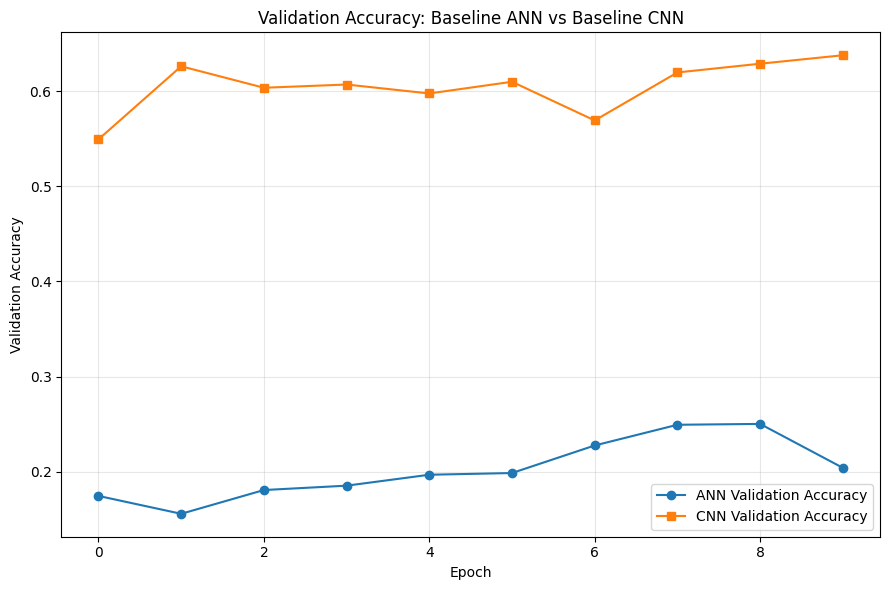

In [10]:
# =============================================================================
# SECTION 6: PLOT -- ANN vs CNN VALIDATION ACCURACY (SAME GRAPH)
# =============================================================================

plt.figure(figsize=(9, 6))
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation Accuracy', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy', marker='s')
plt.title('Validation Accuracy: Baseline ANN vs Baseline CNN')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 7. Task 1 -- Improve ANN Architecture

**What we changed vs. the baseline, and why:**

| Change | Baseline ANN | Improved ANN | Reasoning |
|---|---|---|---|
| Depth | 2 hidden layers | 4 hidden layers | More layers let the network build more abstract, hierarchical representations from raw pixels before classifying. |
| Width | 256 -> 128 | 1024 -> 512 -> 256 -> 128 | Wider early layers retain more raw information from the 3,072-pixel input before compressing it down. |
| Dropout placement | Flat 0.3 everywhere | Graduated 0.5 -> 0.4 -> 0.3 -> 0.3 | Heavier dropout near the input-facing wide layers (which have the most capacity to overfit) and lighter dropout near the output (which needs more stable signal for classification). |
| Regularization | Dropout only | Dropout + BatchNormalization | BatchNorm after each Dense layer keeps the distribution of activations stable as the network gets deeper, which matters more as depth increases. |

This is "Task 1" exactly as required: deeper hidden layers, increased Dense configurations, and strategic Dropout placement -- all explained.


In [11]:
# =============================================================================
# SECTION 7 (TASK 1): IMPROVED ANN ARCHITECTURE
# =============================================================================

def build_improved_ann():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),

        layers.Dense(1024, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),                    # heavy dropout: largest, most overfit-prone layer

        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),                    # lighter dropout near output for stable signal

        layers.Dense(10, activation='softmax')
    ], name="Improved_ANN")
    return model

ann_improved = build_improved_ann()

ann_improved.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

ann_improved.summary()


Model: "Improved_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,234 (14.66 MB)

 Trainable params: 3,840,650 (14.65 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [12]:
# ---- Train Improved ANN for 10 epochs (matching baseline for fair comparison) ----
start = time.time()

history_ann_improved = ann_improved.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    verbose=1
)

print(f"Improved ANN training time: {time.time() - start:.1f}s")


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.2253 - loss: 2.4044 - val_accuracy: 0.2957 - val_loss: 1.9761
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.2770 - loss: 2.0487 - val_accuracy: 0.2976 - val_loss: 1.9584
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2854 - loss: 2.0190 - val_accuracy: 0.3115 - val_loss: 1.9591
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2805 - loss: 2.0352 - val_accuracy: 0.3209 - val_loss: 1.9593
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2772 - loss: 2.0639 - val_accuracy: 0.2997 - val_loss: 2.0128
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2727 - loss: 2.0837 - val_accuracy: 0.3062 - val_loss: 2.0380
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.2672 - loss: 2.1058 - val_accuracy: 0.2886 - val_loss: 2.0621
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.2620 - loss: 2.1399 - 

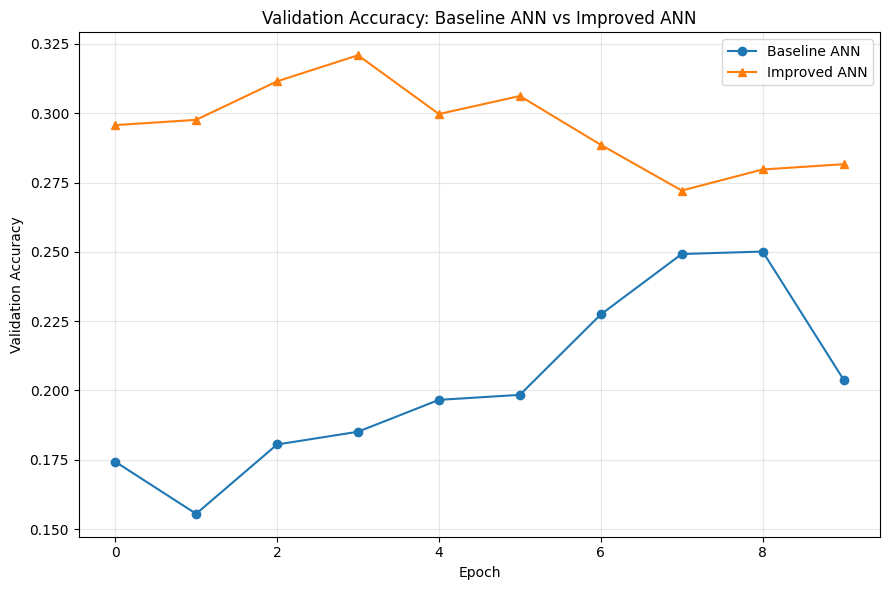

Baseline ANN best val_accuracy : 0.2501
Improved ANN best val_accuracy : 0.3209
Improvement: 7.08 percentage points


In [13]:
# ---- Compare Baseline ANN vs Improved ANN -----------------------------------

plt.figure(figsize=(9, 6))
plt.plot(history_ann.history['val_accuracy'], label='Baseline ANN', marker='o')
plt.plot(history_ann_improved.history['val_accuracy'], label='Improved ANN', marker='^')
plt.title('Validation Accuracy: Baseline ANN vs Improved ANN')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

baseline_ann_acc = max(history_ann.history['val_accuracy'])
improved_ann_acc = max(history_ann_improved.history['val_accuracy'])
print(f"Baseline ANN best val_accuracy : {baseline_ann_acc:.4f}")
print(f"Improved ANN best val_accuracy : {improved_ann_acc:.4f}")
print(f"Improvement: {(improved_ann_acc - baseline_ann_acc) * 100:.2f} percentage points")


---
## 8. Task 2 -- Improve CNN Architecture





In [14]:
# =============================================================================
# SECTION 8 (TASK 2): IMPROVED CNN -- 32 -> 64 -> 128 FILTERS + BATCHNORM
# =============================================================================

def build_improved_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # ---- Block 1: 32 filters -- low-level features (edges, colors) ----
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ---- Block 2: 64 filters -- mid-level features (textures, shapes) ----
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # ---- Block 3: 128 filters -- high-level features (object parts) ----
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ], name="Improved_CNN")
    return model

cnn_improved = build_improved_cnn()

cnn_improved.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cnn_improved.summary()


Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,818 (2.55 MB)

 Trainable params: 667,178 (2.55 MB)

 Non-trainable params: 640 (2.50 KB)

In [15]:
# ---- Train Improved CNN for 10 epochs (baseline comparison point) ----------
start = time.time()

history_cnn_improved_10ep = cnn_improved.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    verbose=1
)

print(f"Improved CNN (10 epochs) training time: {time.time() - start:.1f}s")


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.3846 - loss: 4.3494 - val_accuracy: 0.5626 - val_loss: 1.4478
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5825 - loss: 1.3730 - val_accuracy: 0.6361 - val_loss: 1.0768
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.6630 - loss: 1.0304 - val_accuracy: 0.6673 - val_loss: 1.0535
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6991 - loss: 0.9374 - val_accuracy: 0.7047 - val_loss: 1.0188
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.7215 - loss: 0.9298 - val_accuracy: 0.7259 - val_loss: 0.9893
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.7380 - loss: 0.9432 - val_accuracy: 0.6789 - val_loss: 1.2918
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7520 - loss: 0.9761 - val_accuracy: 0.7009 - val_loss: 1.4876
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7666 - loss: 1.0155 - 

---
## 9. Task 3 -- Extended Training (20 Epochs)



In [16]:
# =============================================================================
# SECTION 9 (TASK 3): EXTENDED TRAINING -- IMPROVED CNN FOR 20 EPOCHS
# =============================================================================

# Fresh model instance so the 20-epoch run starts from the same initialization
# strategy as the 10-epoch run, giving a fair apples-to-apples comparison.
cnn_improved_20ep = build_improved_cnn()
cnn_improved_20ep.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

start = time.time()

history_cnn_improved_20ep = cnn_improved_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    verbose=1
)

print(f"Improved CNN (20 epochs) training time: {time.time() - start:.1f}s")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 39ms/step - accuracy: 0.3807 - loss: 4.3734 - val_accuracy: 0.5105 - val_loss: 1.7619
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.5778 - loss: 1.3825 - val_accuracy: 0.6461 - val_loss: 1.0617
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6626 - loss: 1.0138 - val_accuracy: 0.6615 - val_loss: 1.0130
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6990 - loss: 0.9291 - val_accuracy: 0.6985 - val_loss: 0.9754
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.7185 - loss: 0.9198 - val_accuracy: 0.7023 - val_loss: 1.0471
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.7314 - loss: 0.9602 - val_accuracy: 0.7259 - val_loss: 1.0591
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7478 - loss: 0.9862 - val_accuracy: 0.7168 - val_loss: 1.1670
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7653 - loss: 0.9865 - 

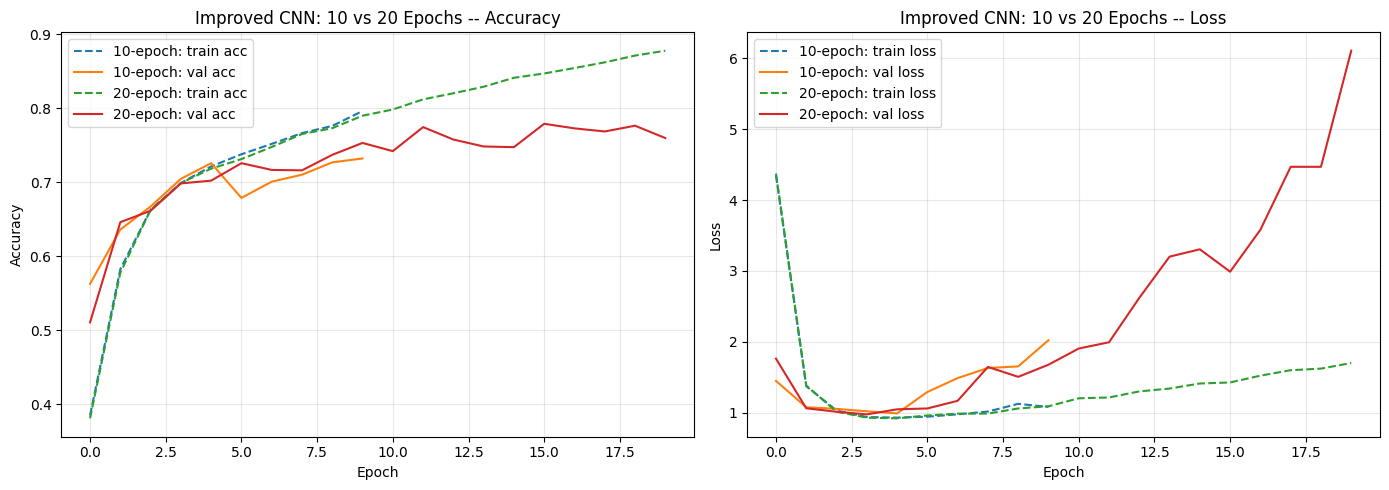

10-epoch best val_accuracy: 0.7323
20-epoch best val_accuracy: 0.7792
10-epoch final train-val accuracy gap: 0.0641
20-epoch final train-val accuracy gap: 0.1181


In [17]:
# ---- Compare 10-epoch vs 20-epoch training/validation curves ----------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_cnn_improved_10ep.history['accuracy'], '--', label='10-epoch: train acc')
axes[0].plot(history_cnn_improved_10ep.history['val_accuracy'], '-', label='10-epoch: val acc')
axes[0].plot(history_cnn_improved_20ep.history['accuracy'], '--', label='20-epoch: train acc')
axes[0].plot(history_cnn_improved_20ep.history['val_accuracy'], '-', label='20-epoch: val acc')
axes[0].set_title('Improved CNN: 10 vs 20 Epochs -- Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss comparison
axes[1].plot(history_cnn_improved_10ep.history['loss'], '--', label='10-epoch: train loss')
axes[1].plot(history_cnn_improved_10ep.history['val_loss'], '-', label='10-epoch: val loss')
axes[1].plot(history_cnn_improved_20ep.history['loss'], '--', label='20-epoch: train loss')
axes[1].plot(history_cnn_improved_20ep.history['val_loss'], '-', label='20-epoch: val loss')
axes[1].set_title('Improved CNN: 10 vs 20 Epochs -- Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"10-epoch best val_accuracy: {max(history_cnn_improved_10ep.history['val_accuracy']):.4f}")
print(f"20-epoch best val_accuracy: {max(history_cnn_improved_20ep.history['val_accuracy']):.4f}")
print(f"10-epoch final train-val accuracy gap: "
      f"{history_cnn_improved_10ep.history['accuracy'][-1] - history_cnn_improved_10ep.history['val_accuracy'][-1]:.4f}")
print(f"20-epoch final train-val accuracy gap: "
      f"{history_cnn_improved_20ep.history['accuracy'][-1] - history_cnn_improved_20ep.history['val_accuracy'][-1]:.4f}")


---
## 10. Task 4 -- Early Stopping


In [18]:
# =============================================================================
# SECTION 10 (TASK 4): EARLY STOPPING CALLBACK
# =============================================================================

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Fresh model instance for a clean EarlyStopping demonstration.
cnn_early_stop = build_improved_cnn()
cnn_early_stop.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

start = time.time()

history_cnn_early_stop = cnn_early_stop.fit(
    x_train_norm, y_train,
    epochs=20,                  # set a generous upper bound; EarlyStopping decides the real stopping point
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    callbacks=[early_stop],
    verbose=1
)

actual_epochs_trained = len(history_cnn_early_stop.history['loss'])
print(f"\nTraining stopped after {actual_epochs_trained} epochs (cap was 20).")
print(f"EarlyStopping training time: {time.time() - start:.1f}s")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.3837 - loss: 4.3730 - val_accuracy: 0.5301 - val_loss: 1.6145
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5733 - loss: 1.4055 - val_accuracy: 0.6083 - val_loss: 1.1751
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6618 - loss: 1.0263 - val_accuracy: 0.6772 - val_loss: 1.0350
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6982 - loss: 0.9402 - val_accuracy: 0.7097 - val_loss: 0.9631
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.7201 - loss: 0.9251 - val_accuracy: 0.7289 - val_loss: 0.9576
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7346 - loss: 0.9581 - val_accuracy: 0.7091 - val_loss: 1.2036
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.7516 - loss: 0.9671 - val_accuracy: 0.7089 - val_loss: 1.3987
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7690 - loss: 0.9870 - 

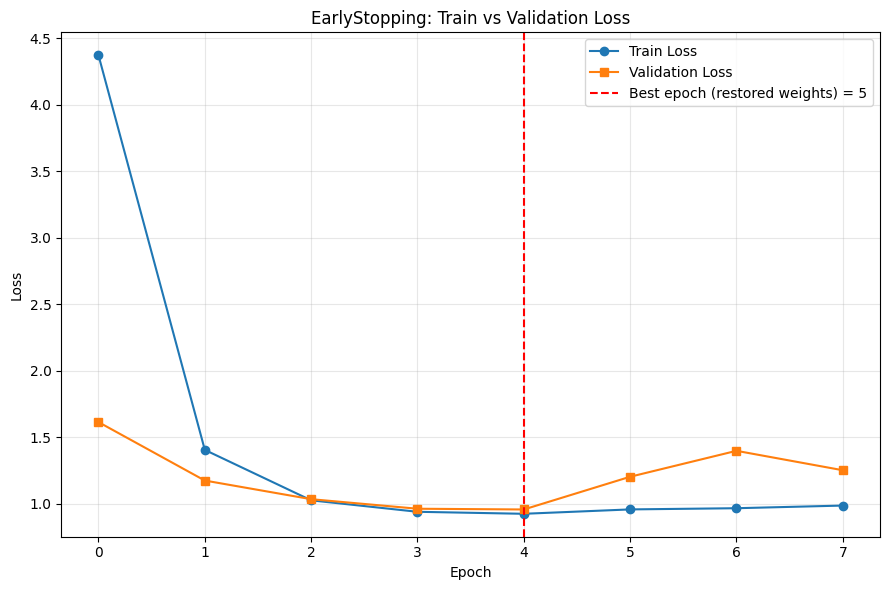

In [19]:
# ---- Visualize where EarlyStopping intervened -------------------------------

plt.figure(figsize=(9, 6))
plt.plot(history_cnn_early_stop.history['loss'], label='Train Loss', marker='o')
plt.plot(history_cnn_early_stop.history['val_loss'], label='Validation Loss', marker='s')
best_epoch = int(np.argmin(history_cnn_early_stop.history['val_loss']))
plt.axvline(best_epoch, color='red', linestyle='--',
            label=f'Best epoch (restored weights) = {best_epoch + 1}')
plt.title('EarlyStopping: Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 11. Task 5 -- Data Augmentation



In [20]:
# =============================================================================
# SECTION 11 (TASK 5): DATA AUGMENTATION -- ADVANCED AUGMENTED CNN
# =============================================================================

# Augmentation layers run ONLY during training; they pass through unchanged
# data during evaluation/inference automatically.
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="Augmentation_Pipeline")

def build_augmented_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,                      # <-- augmentation applied first

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ], name="Augmented_CNN")
    return model

cnn_augmented = build_augmented_cnn()

cnn_augmented.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cnn_augmented.summary()


Model: "Augmented_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Augmentation_Pipeline           │ (None, 32, 32, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

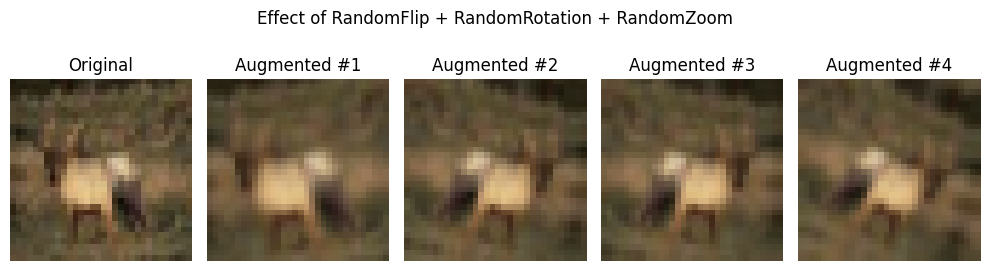

In [21]:
# ---- Visualize the augmentation effect on a sample image --------------------

sample_image = x_train_norm[3:4]  # keep batch dimension

plt.figure(figsize=(10, 3))
plt.subplot(1, 5, 1)
plt.imshow(sample_image[0])
plt.title("Original")
plt.axis('off')

for i in range(4):
    augmented_image = data_augmentation(sample_image, training=True)
    plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_image[0].numpy())
    plt.title(f"Augmented #{i+1}")
    plt.axis('off')

plt.suptitle("Effect of RandomFlip + RandomRotation + RandomZoom")
plt.tight_layout()
plt.show()


In [22]:
# ---- Train the Augmented CNN with EarlyStopping (best-practice combination) ----
early_stop_aug = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start = time.time()

history_cnn_augmented = cnn_augmented.fit(
    x_train_norm, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test_norm, y_test),
    callbacks=[early_stop_aug],
    verbose=1
)

print(f"Augmented CNN training time: {time.time() - start:.1f}s")


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - accuracy: 0.3183 - loss: 4.7800 - val_accuracy: 0.4978 - val_loss: 1.4917
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.4461 - loss: 1.7119 - val_accuracy: 0.5389 - val_loss: 1.3233
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.5087 - loss: 1.4388 - val_accuracy: 0.5080 - val_loss: 1.4709
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.5322 - loss: 1.4061 - val_accuracy: 0.5647 - val_loss: 1.4523
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.5476 - loss: 1.4365 - val_accuracy: 0.5998 - val_loss: 1.3137
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5554 - loss: 1.4822 - val_accuracy: 0.5403 - val_loss: 1.9479
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step - accuracy: 0.5627 - loss: 1.5345 - val_accuracy: 0.5844 - val_loss: 1.5401
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5778 - loss: 1.5328 - 

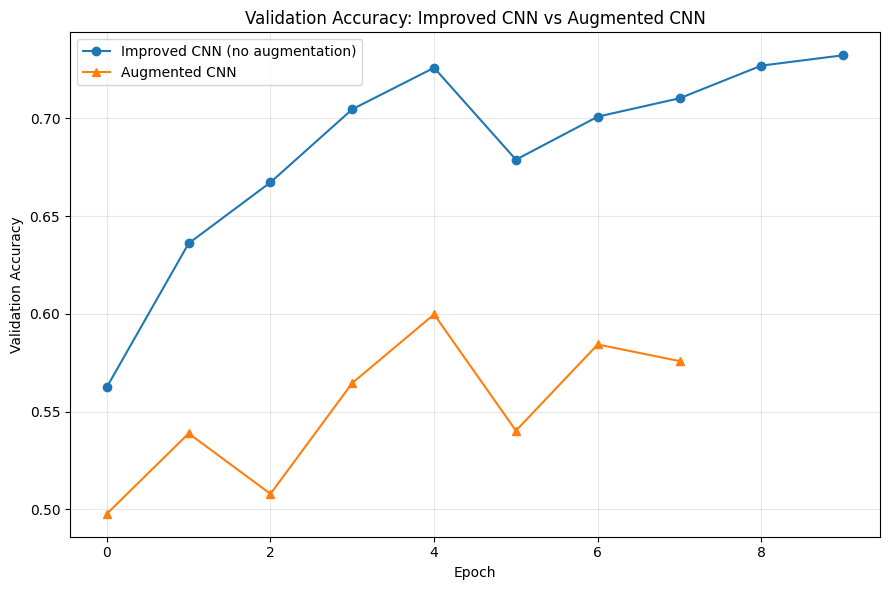

In [23]:
# ---- Plot validation accuracy: Improved CNN vs Augmented CNN ----------------

plt.figure(figsize=(9, 6))
plt.plot(history_cnn_improved_10ep.history['val_accuracy'], label='Improved CNN (no augmentation)', marker='o')
plt.plot(history_cnn_augmented.history['val_accuracy'], label='Augmented CNN', marker='^')
plt.title('Validation Accuracy: Improved CNN vs Augmented CNN')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---
## 12. Deliverable 3 -- Final Comparison DataFrame

We now evaluate **every model** on the held-out test set (`x_test_norm`, `y_test`) using `model.evaluate()`, which gives the true generalization performance -- not just the last validation accuracy seen during training (the two can differ slightly because `evaluate()` runs in a single deterministic pass with no augmentation / dropout active).


In [24]:
# =============================================================================
# SECTION 12: FINAL TEST-SET EVALUATION -- ALL MODELS
# =============================================================================

print("Evaluating all models on the held-out test set...\n")

_, ann_baseline_test_acc = ann_baseline.evaluate(x_test_norm, y_test, verbose=0)
_, ann_improved_test_acc = ann_improved.evaluate(x_test_norm, y_test, verbose=0)
_, cnn_baseline_test_acc = cnn_baseline.evaluate(x_test_norm, y_test, verbose=0)
_, cnn_improved_test_acc = cnn_improved.evaluate(x_test_norm, y_test, verbose=0)          # 10-epoch improved CNN
_, cnn_improved_20ep_test_acc = cnn_improved_20ep.evaluate(x_test_norm, y_test, verbose=0)  # 20-epoch improved CNN
_, cnn_early_stop_test_acc = cnn_early_stop.evaluate(x_test_norm, y_test, verbose=0)
_, cnn_augmented_test_acc = cnn_augmented.evaluate(x_test_norm, y_test, verbose=0)

print("Baseline ANN          Test Accuracy: {:.2f}%".format(ann_baseline_test_acc * 100))
print("Improved ANN          Test Accuracy: {:.2f}%".format(ann_improved_test_acc * 100))
print("Baseline CNN          Test Accuracy: {:.2f}%".format(cnn_baseline_test_acc * 100))
print("Improved CNN (10 ep)  Test Accuracy: {:.2f}%".format(cnn_improved_test_acc * 100))
print("Improved CNN (20 ep)  Test Accuracy: {:.2f}%".format(cnn_improved_20ep_test_acc * 100))
print("Improved CNN + EarlyStopping Test Accuracy: {:.2f}%".format(cnn_early_stop_test_acc * 100))
print("Augmented CNN         Test Accuracy: {:.2f}%".format(cnn_augmented_test_acc * 100))


Evaluating all models on the held-out test set...

Baseline ANN          Test Accuracy: 20.39%
Improved ANN          Test Accuracy: 28.16%
Baseline CNN          Test Accuracy: 63.81%
Improved CNN (10 ep)  Test Accuracy: 73.23%
Improved CNN (20 ep)  Test Accuracy: 75.99%
Improved CNN + EarlyStopping Test Accuracy: 72.89%
Augmented CNN         Test Accuracy: 59.98%


In [25]:
# =============================================================================
# SECTION 12 (CONT.): FINAL COMPARISON DATAFRAME (sorted by accuracy, descending)
# =============================================================================

results = pd.DataFrame({
    "Model": [
        "ANN Baseline",
        "Improved ANN",
        "CNN Baseline",
        "Improved CNN (10 epochs)",
        "Improved CNN (20 epochs)",
        "Improved CNN + EarlyStopping",
        "Augmented CNN"
    ],
    "Test Accuracy (%)": [
        round(ann_baseline_test_acc * 100, 2),
        round(ann_improved_test_acc * 100, 2),
        round(cnn_baseline_test_acc * 100, 2),
        round(cnn_improved_test_acc * 100, 2),
        round(cnn_improved_20ep_test_acc * 100, 2),
        round(cnn_early_stop_test_acc * 100, 2),
        round(cnn_augmented_test_acc * 100, 2),
    ]
})

results_sorted = results.sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)

best_model_name = results_sorted.iloc[0]["Model"]
best_model_acc = results_sorted.iloc[0]["Test Accuracy (%)"]

print(f"BEST PERFORMING MODEL: {best_model_name}  ({best_model_acc}% test accuracy)\n")
results_sorted


BEST PERFORMING MODEL: Improved CNN (20 epochs)  (75.99% test accuracy)



,Model,Test Accuracy (%)
0,Improved CNN (20 epochs),75.99
1,Improved CNN (10 epochs),73.23
2,Improved CNN + EarlyStopping,72.89
3,CNN Baseline,63.81
4,Augmented CNN,59.98
5,Improved ANN,28.16
6,ANN Baseline,20.39


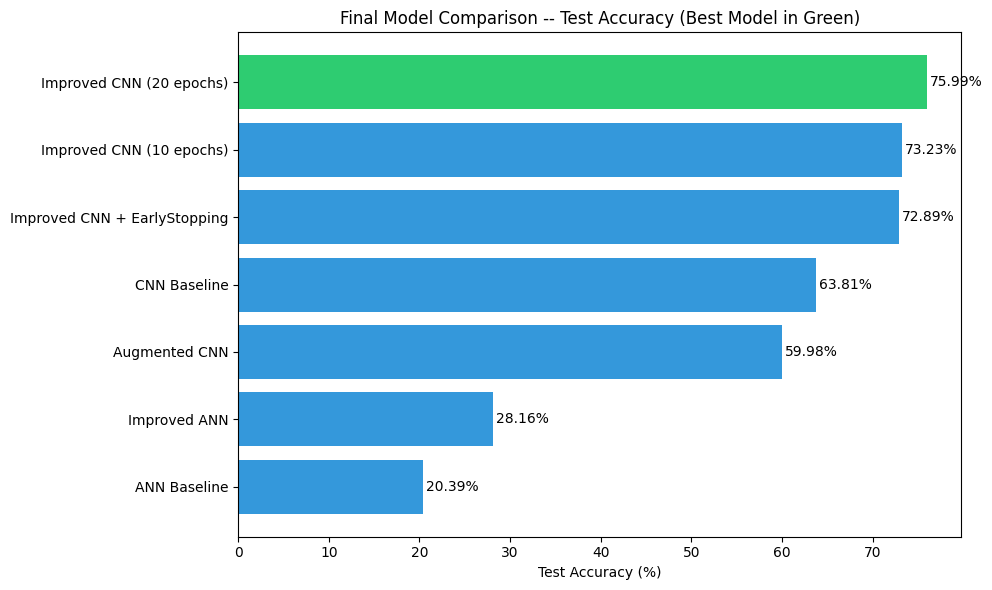

In [26]:
# ---- Visualize final comparison as a bar chart -------------------------------

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in results_sorted['Model']]
plt.barh(results_sorted['Model'], results_sorted['Test Accuracy (%)'], color=colors)
plt.xlabel('Test Accuracy (%)')
plt.title('Final Model Comparison -- Test Accuracy (Best Model in Green)')
plt.gca().invert_yaxis()
for i, v in enumerate(results_sorted['Test Accuracy (%)']):
    plt.text(v + 0.3, i, f"{v}%", va='center')
plt.tight_layout()
plt.show()
